In [1]:
import os 
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

!nvidia-smi

Tue Aug 26 20:54:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.76.05              Driver Version: 580.76.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:19:00.0 Off |                  Off |
|  0%   46C    P8             25W /  450W |      45MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from backbones.dit import DiT

# 사용 예
model = DiT()
print(model)

/home/scpark/miniconda3/envs/rbf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-08-26 20:54:08.057950: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/scpark/miniconda3/envs/rbf/lib/python3.11/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/scpark/miniconda3/envs/rbf/lib/python3.11

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def display_class_images(pixel_samples, class_ids=None, figsize_per_image=3.5, display_title=""):
    samples = list(pixel_samples)
    processed = []
    for img in samples:
        if isinstance(img, Image.Image):
            arr = np.array(img)
        else:
            arr = np.array(img)
            if arr.ndim == 3 and arr.shape[0] in (1,3):
                arr = arr.transpose(1, 2, 0)
        processed.append(arr)

    n = len(processed)
    if class_ids is None:
        class_ids = list(range(n))

    fig, axes = plt.subplots(1, n, figsize=(n * figsize_per_image, figsize_per_image))
    if n == 1:
        axes = [axes]

    # 전체 제목 추가
    if display_title:
        fig.suptitle(display_title, fontsize=10, y=1.1)  # y 값을 1.02로 올려서 제목을 위로 이동
    # 플롯 레이아웃 조정: top을 낮춰서 제목과 플롯 사이에 공간 확보
    
    for ax, img_arr, lbl in zip(axes, processed, class_ids):
        ax.imshow(img_arr)
        ax.axis("off")
        ax.set_title(f"Class {lbl}", fontsize=8)

    plt.show()


In [37]:
from solvers.others.dpm_solver import DPM_Solver
from solvers.others.euler_solver import Euler_Solver

# 클래스 0–9로 설정
class_start = np.random.randint(0, 900)
#class_start = 0
class_ids = [i for i in range(class_start, class_start+100, 10)]
noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=class_ids, guidance_scale=3.0)
noises = model.get_noise(seeds=class_ids)


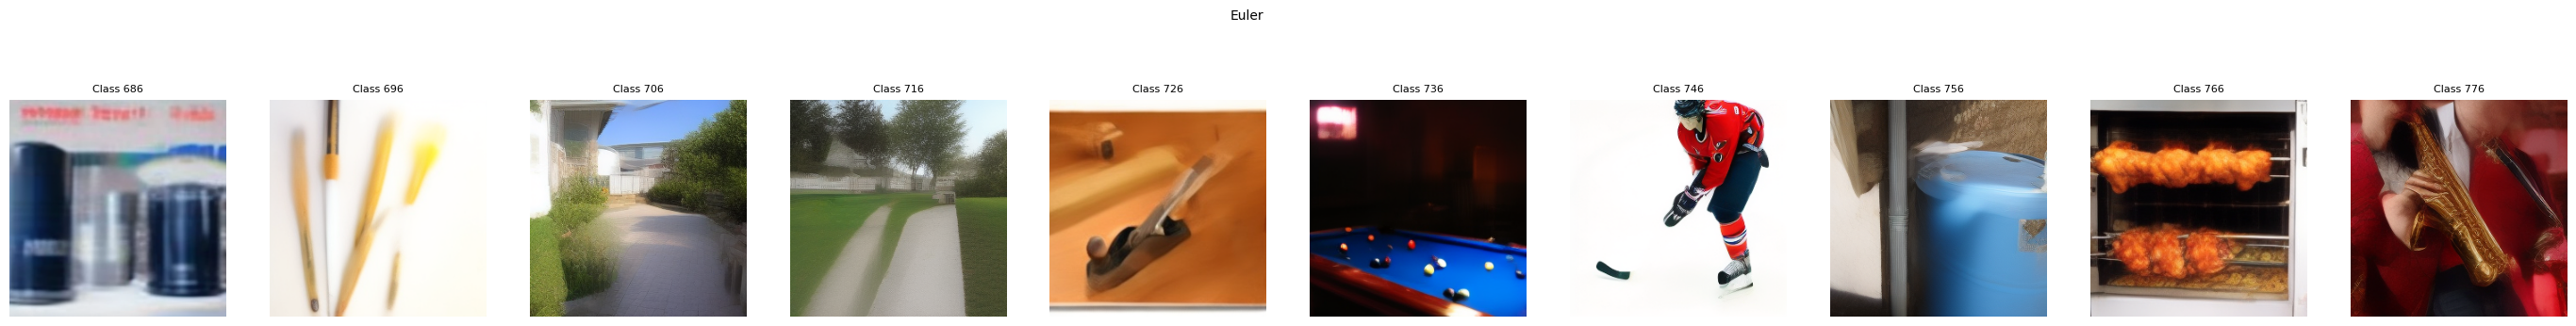

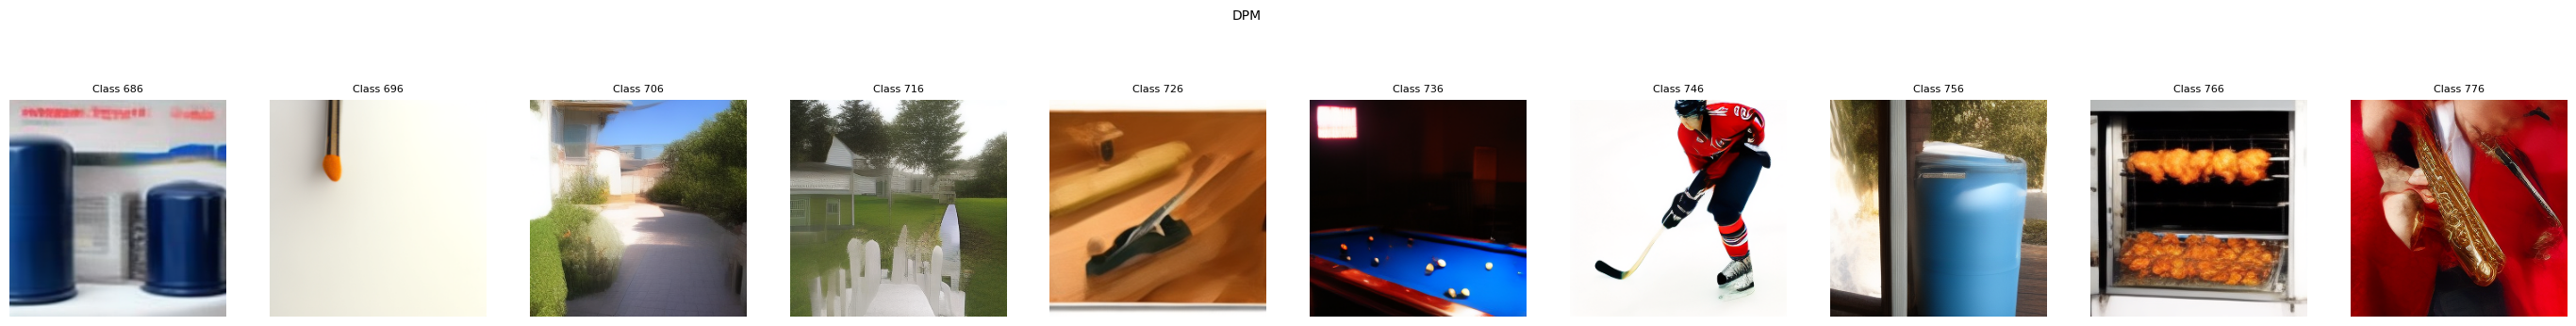

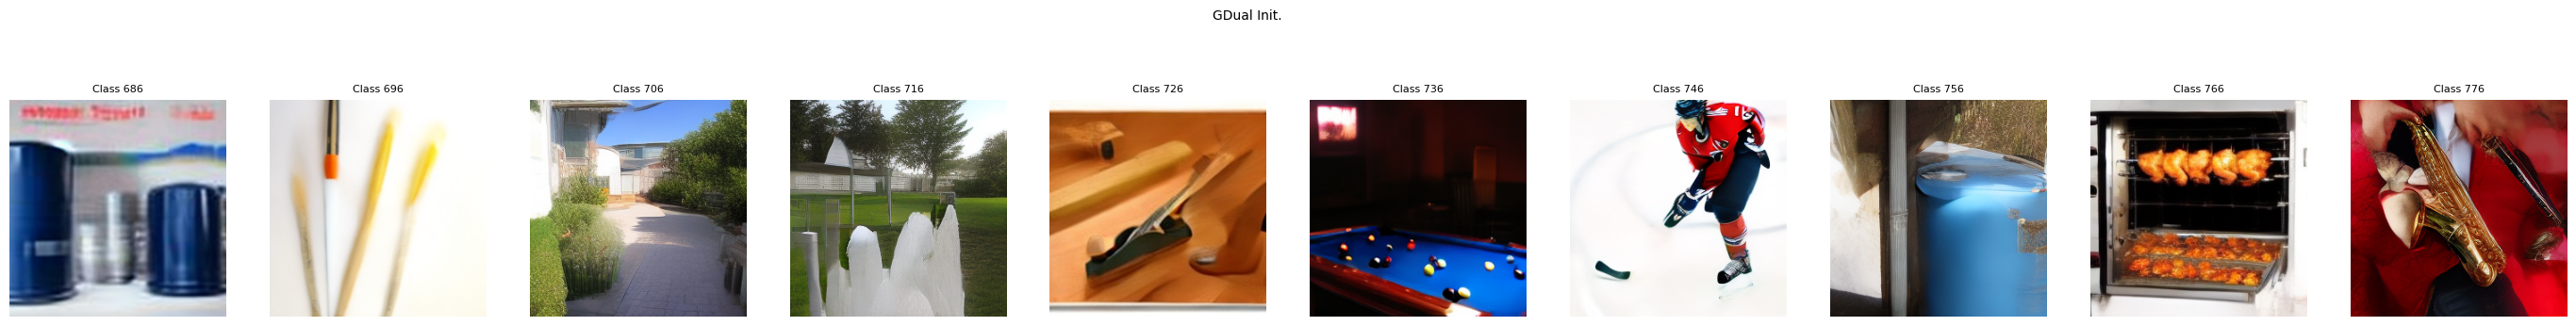

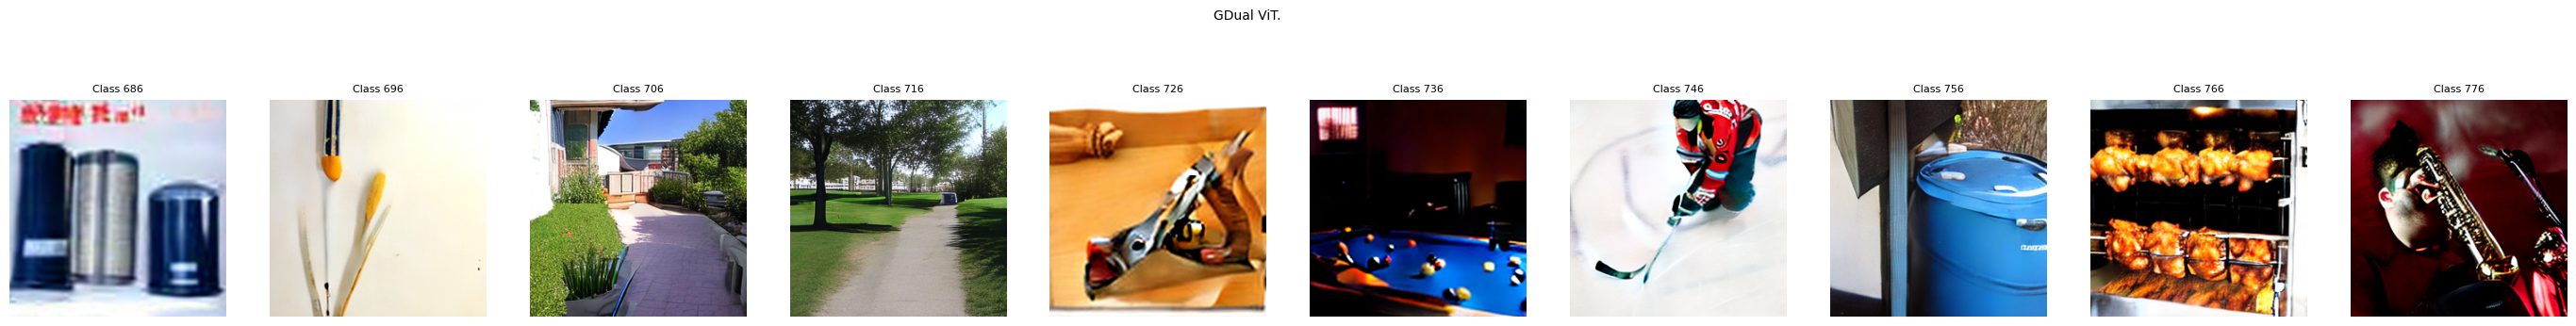

In [38]:
import torch
NFE = 5
solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
latents = solver.sample(noises, model_fn)['samples']
samples = model.decode_vae(latents, raw_output=False, pil_output=True)
display_class_images(samples['pil_output'], class_ids, display_title='Euler')

solver = DPM_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
latents = solver.sample(noises, model_fn)['samples']
samples = model.decode_vae(latents, raw_output=False, pil_output=True)
display_class_images(samples['pil_output'], class_ids, display_title='DPM')

from solvers.taylor.solver.gdual_solver import GDual_Solver
from solvers.taylor.transform.logaffine_transform import LogAffineTransform
from solvers.taylor.extractor.table_extractor import Extractor

noise_schedule = model.get_noise_schedule()
extractor = Extractor(steps=NFE)
transform = LogAffineTransform(gamma_push=True, gamma_max=2, tau_offset=1, kappa_max=2, eps=1e-2)
solver = GDual_Solver(
    noise_schedule,
    steps=NFE,
    transform=transform,
    param_extractor=extractor,
    skip_type="time_uniform",
    pred_order=1,
    corr_order=2,
    order1_kappa=True,
    order2_kappa=True,
    use_corrector=True,
    time_learning=True,
    train_mode=True
).to(model.device)

with torch.no_grad():
    latents = solver.sample(noises, model_fn)
    samples = model.decode_vae(latents, raw_output=False, pil_output=True)
display_class_images(samples['pil_output'], class_ids, display_title='GDual Init.')


pt_file = 'logs/dit/s5/step_00010000.pt'
state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    latents = solver.sample(noises, model_fn)
    samples = model.decode_vae(latents, raw_output=False, pil_output=True)
display_class_images(samples['pil_output'], class_ids, display_title='GDual ViT.')


# NFE = 20
# solver = Euler_Solver(noise_schedule, steps=NFE, skip_type='time_uniform', algorithm_type="data_prediction")
# latents = solver.sample(latents, model_fn)['samples']
# samples = model.decode_vae(latents)
# display_class_images(samples, class_ids, display_title='Euler 20steps')

In [50]:
from pathlib import Path
import re
from tensorboard.backend.event_processing import event_accumulator as ea

def get_best_pt(pt_dir: str, label: str):
    acc = ea.EventAccumulator(pt_dir, size_guidance={ea.SCALARS: 0}); acc.Reload()
    vals = {e.step: e.value for e in acc.Scalars(label)}  # step -> scalar

    files = {int(m.group(1)): str(p)
             for p in Path(pt_dir).glob("step_*.pt")
             for m in [re.search(r"step_(\d+)\.pt$", p.name)] if m}

    cands = [(vals[s], s, f) for s, f in files.items() if s in vals]
    return min(cands)[2] if cands else None

best_path = get_best_pt("logs/dit/s3", "train_loss")
print(best_path)


logs/dit/s3/step_00007500.pt
